# A6: Full TOPSIS — Individual Foods & Diet-Level Ranking

**Input:** foundation_analysis_ready.csv  
**Output:** foundation_topsis_ranking.csv, foundation_topsis_diets.csv

**What changed from A5:**  
- Diet sections (4 & 5) now use **TOPSIS** instead of Pareto  
- No Pareto front size problem — every diet gets a 0–1 score, top-50 highlighted, remaining ~N plotted as grey  
- Diet count can be scaled to 100k or 1M without any Pareto bottleneck  

**Why TOPSIS everywhere?** Pareto with 20 objectives produces fronts containing 80%+ of all points (individual foods) or thousands of diets — both unplottable. TOPSIS collapses all objectives to a single interpretable score, enabling clean top-N rankings and scalable sampling.

## Methodology

### Overview
This notebook provides the final, scalable ranking of both individual foods and randomly generated diets using **TOPSIS** (Technique for Order of Preference by Similarity to Ideal Solution) across all 20 nutritional objectives simultaneously.

### Why TOPSIS instead of Pareto?
With 20 objectives, Pareto optimality breaks down due to the curse of dimensionality: in high-dimensional objective space, almost every point is non-dominated because it is easy to be "best" on at least one obscure dimension. In practice, running Pareto on all 20 objectives yields a front containing ~80% of all foods — which is not informative. TOPSIS solves this by collapsing all objectives into a single scalar score:

1. Min-max normalize each objective to [0, 1]
2. Invert maximize objectives so all are in "cost" direction (lower = better)
3. Apply weights (equal by default)
4. For each food, compute **d⁺** (Euclidean distance to the ideal point — best on all objectives) and **d⁻** (distance to the anti-ideal — worst on all)
5. TOPSIS score = d⁻ / (d⁺ + d⁻) — ranges from 0 to 1, where 1.0 means the food is the closest possible to perfect on all 20 objectives simultaneously

This produces a full ranking with no ties and no dimensionality collapse issues.

### Objectives (20 total)
- **Minimize** (7): price, CO2, sodium, saturated fat, cholesterol, trans fat, total sugars — all per 1000 kcal
- **Maximize** (13): protein, fiber, calcium, iron, magnesium, potassium, vitamins A/B12/C/D, zinc, monounsaturated fat, polyunsaturated fat — all per 1000 kcal

### Diet Generation & Scoring
Random diets are generated by sampling 5 or 10 foods uniformly at random from the valid product pool (equal probability per diet size). Each diet is a fixed 2000 kcal: individual food contributions are scaled to target_kcal/1000 before summing nutrient objectives. With N_DIETS = 1,000,000, the sampling covers the diet space densely enough that top-ranked diets are stable across runs (verified by re-seeding). TOPSIS is then applied to the full diet matrix in a single vectorized operation — no Pareto bottleneck.

Group-based diets sample one product per food group slot (10 slots with replacement), enforcing dietary diversity by construction. These are scored identically and reported separately to allow comparison between unconstrained and diversity-constrained optima.

In [19]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

In [20]:
# ── Tuneable parameters ──────────────────────────────────────────────────────
N_DIETS        = 1000_000   # total random diets to generate (increase to 1_000_000 if RAM allows)
N_TOP_DIETS    = 50        # how many top-TOPSIS diets to highlight in plots
N_GREY_SAMPLE  = 10_000    # grey background dots to plot (random sample from all diets)
RANDOM_SEED    = 42

PALETTE = {
    "meat_fish_eggs":     "#e74c3c",
    "fruits_veg_legumes": "#2ecc71",
    "cereals":            "#f39c12",
    "dairy":              "#3498db",
    "fats":               "#9b59b6",
    "condiments":         "#1abc9c",
    "beverages":          "#34495e",
    "sweets":             "#e91e63",
    "default":            "#95a5a6",
}

AGRIBALYSE_GROUP_LABELS = {
    "viandes, \u0153ufs, poissons":                          "meat_fish_eggs",
    "fruits, l\u00e9gumes, l\u00e9gumineuses et ol\u00e9agineux": "fruits_veg_legumes",
    "produits c\u00e9r\u00e9aliers":                               "cereals",
    "entr\u00e9es et plats compos\u00e9s":                         "prepared_meals",
    "lait et produits laitiers":                         "dairy",
    "aides culinaires et ingr\u00e9dients divers":            "condiments",
    "boissons":                                          "beverages",
    "mati\u00e8res grasses":                                  "fats",
    "produits sucr\u00e9s":                                   "sweets",
    "aliments infantiles":                               "infant",
    "glaces et sorbets":                                 "ice_cream",
}

## 1. Load Data & Compute per_1000kcal Columns

In [21]:
df = pd.read_csv("foundation_analysis_ready.csv")
df["group_en"] = df["co2_group"].map(AGRIBALYSE_GROUP_LABELS).fillna("other")

_eps = 1e-9

# All per_100kcal → per_1000kcal (×10)
per100_cols = [c for c in df.columns if c.endswith("_per_100kcal")]
for col in per100_cols:
    df[col.replace("_per_100kcal", "_per_1000kcal")] = df[col] * 10

# Energy density: Energy[kcal] is per 100g
df["kcal_per_kg"] = df["Energy [kcal]"] * 10

# Price and CO2 per 1000 kcal
df["price_per_1000kcal"] = df["price_per_kg"] * (1000 / (df["kcal_per_kg"] + _eps))
df["co2_per_1000kcal"]   = df["co2_kg_final"] * (1000 / (df["kcal_per_kg"] + _eps))

print("Shape:", df.shape)
print("\nSample per_1000kcal stats:")
for c in ["price_per_1000kcal", "co2_per_1000kcal", "Protein_per_1000kcal", "Sodium_Na_per_1000kcal"]:
    print(f"  {c}: [{df[c].min():.2f}, {df[c].max():.2f}]  mean={df[c].mean():.2f}")

Shape: (357, 56)

Sample per_1000kcal stats:
  price_per_1000kcal: [0.30, 60.49]  mean=7.56
  co2_per_1000kcal: [0.11, 38.72]  mean=3.38
  Protein_per_1000kcal: [0.00, 242.47]  mean=67.95
  Sodium_Na_per_1000kcal: [0.00, 67333.33]  mean=1442.21


## 2. Define Objectives

In [22]:
MINIMIZE_COLS = [
    "price_per_1000kcal",
    "co2_per_1000kcal",
    "Sodium_Na_per_1000kcal",
    "Fatty_acids_total_saturated_per_1000kcal",
    "Cholesterol_per_1000kcal",
    "Fatty_acids_total_trans_per_1000kcal",
    "Sugars_Total_per_1000kcal",
]

MAXIMIZE_COLS = [
    "Protein_per_1000kcal",
    "Fiber_total_dietary_per_1000kcal",
    "Calcium_Ca_per_1000kcal",
    "Iron_Fe_per_1000kcal",
    "Magnesium_Mg_per_1000kcal",
    "Potassium_K_per_1000kcal",
    "Vitamin_A_RAE_per_1000kcal",
    "Vitamin_B-12_per_1000kcal",
    "Vitamin_C_total_ascorbic_acid_per_1000kcal",
    "Vitamin_D_(D2_+_D3)_per_1000kcal",
    "Zinc_Zn_per_1000kcal",
    "Fatty_acids_total_monounsaturated_per_1000kcal",
    "Fatty_acids_total_polyunsaturated_per_1000kcal",
]

ALL_OBJ_COLS = MINIMIZE_COLS + MAXIMIZE_COLS
print(f"Objectives: {len(ALL_OBJ_COLS)} total  ({len(MINIMIZE_COLS)} minimize, {len(MAXIMIZE_COLS)} maximize)")

Objectives: 20 total  (7 minimize, 13 maximize)


## 3. TOPSIS Function

In [23]:
def topsis(df_in, minimize_cols, maximize_cols, weights=None):
    """
    TOPSIS ranking — higher score = closer to ideal solution on all objectives.

    Steps:
      1. Min-max normalize each column to [0,1]
      2. Invert maximize cols so all are in cost direction (lower = better)
      3. Apply weights (dict {col: w} or None for equal)
      4. Compute d+ (distance to ideal=0) and d- (distance to anti-ideal=max)
      5. score = d- / (d+ + d-)  — higher is better

    Accepts DataFrame or ndarray for df_in (ndarray skips column lookup).
    Returns 1-D numpy array of scores aligned to input rows.
    """
    all_cols = minimize_cols + maximize_cols
    if isinstance(df_in, pd.DataFrame):
        X = df_in[all_cols].values.astype(float)
    else:
        X = df_in.astype(float)

    col_min = X.min(axis=0)
    col_max = X.max(axis=0)
    denom = col_max - col_min
    denom[denom == 0] = _eps
    X_norm = (X - col_min) / denom

    n_min = len(minimize_cols)
    X_cost = X_norm.copy()
    X_cost[:, n_min:] = 1.0 - X_norm[:, n_min:]  # invert maximize

    w = np.ones(len(all_cols))
    if weights:
        for i, col in enumerate(all_cols):
            if col in weights:
                w[i] = weights[col]
    w = w / w.sum()
    X_w = X_cost * w

    ideal      = X_w.min(axis=0)
    anti_ideal = X_w.max(axis=0)

    d_plus  = np.sqrt(((X_w - ideal)      ** 2).sum(axis=1))
    d_minus = np.sqrt(((X_w - anti_ideal) ** 2).sum(axis=1))
    return d_minus / (d_plus + d_minus + _eps)

## 4. TOPSIS Ranking on Individual Foods

In [24]:
df_valid = df.dropna(subset=ALL_OBJ_COLS).copy()
print(f"Valid products (no NaN in any objective): {len(df_valid)} / {len(df)}")

df_valid["topsis_score"] = topsis(df_valid, MINIMIZE_COLS, MAXIMIZE_COLS)

top20 = df_valid.nlargest(20, "topsis_score")
cols_show = ["description", "group_en", "topsis_score",
             "price_per_1000kcal", "co2_per_1000kcal",
             "Protein_per_1000kcal", "Fiber_total_dietary_per_1000kcal"]
print("\nTop 20 foods by TOPSIS score (equal weights, 20 objectives):")
print(top20[cols_show].to_string(index=False))

Valid products (no NaN in any objective): 357 / 357

Top 20 foods by TOPSIS score (equal weights, 20 objectives):
                               description           group_en  topsis_score  price_per_1000kcal  co2_per_1000kcal  Protein_per_1000kcal  Fiber_total_dietary_per_1000kcal
                           Spinach, mature fruits_veg_legumes      0.526516            6.162786          3.908795            105.184582                         57.473760
                                 Kale, raw fruits_veg_legumes      0.523165            8.406349          2.037143             83.428571                        117.142857
                             Spinach, baby fruits_veg_legumes      0.522881           35.175927          4.059845            107.205285                         58.567025
    Beans, Dry, Flor de Mayo (0% moisture) fruits_veg_legumes      0.517617            3.224138          0.850010            230.830196                         39.627501
      Beans, Dry, Medium Red (0% moi

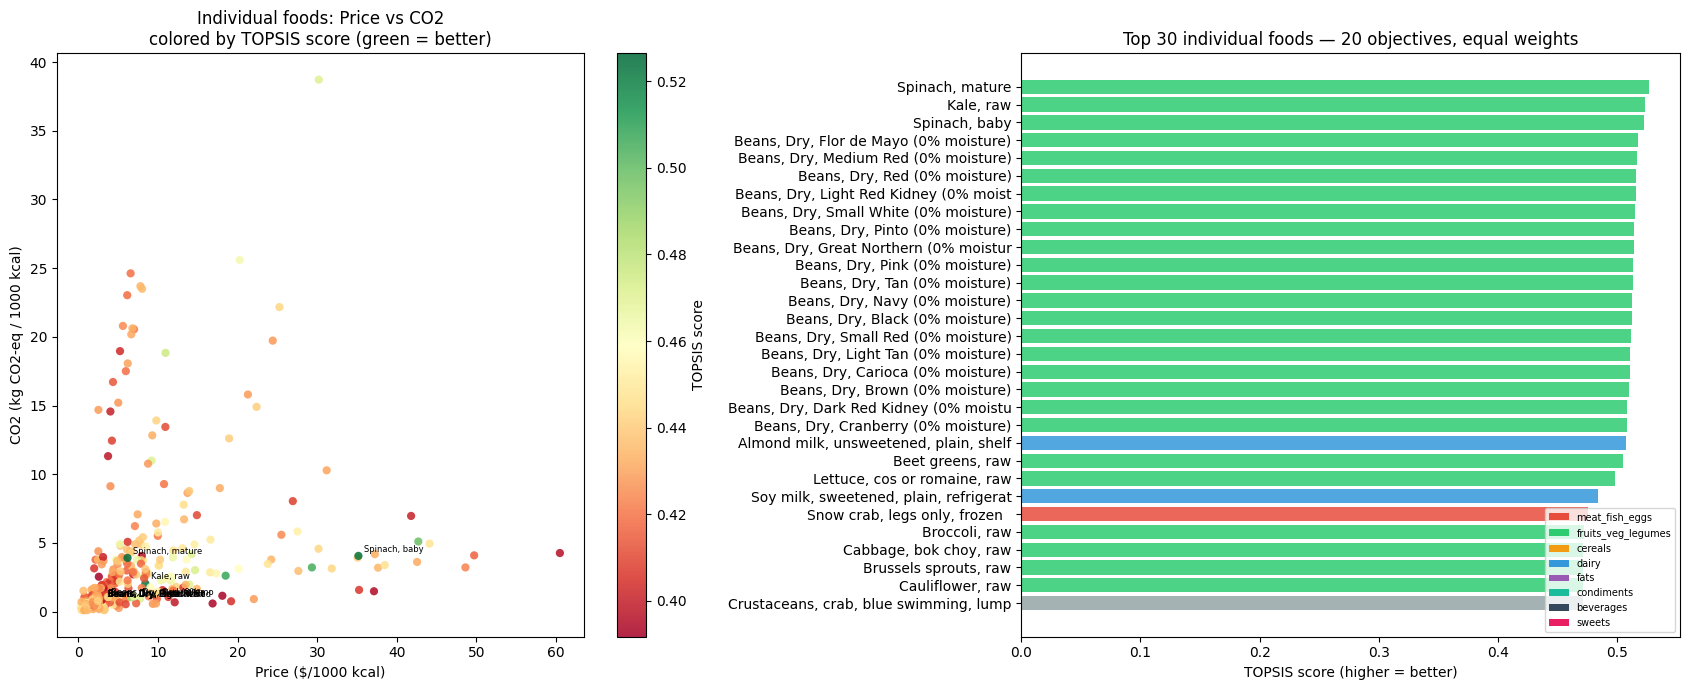

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# Left: price vs CO2 scatter, colored by TOPSIS score
ax = axes[0]
sc = ax.scatter(
    df_valid["price_per_1000kcal"], df_valid["co2_per_1000kcal"],
    c=df_valid["topsis_score"], cmap="RdYlGn",
    s=35, alpha=0.85, edgecolors="none",
)
plt.colorbar(sc, ax=ax, label="TOPSIS score")
top10 = df_valid.nlargest(10, "topsis_score")
for _, r in top10.iterrows():
    ax.annotate(r["description"][:22], (r["price_per_1000kcal"], r["co2_per_1000kcal"]),
                fontsize=6, xytext=(4, 3), textcoords="offset points")
ax.set_xlabel("Price ($/1000 kcal)")
ax.set_ylabel("CO2 (kg CO2-eq / 1000 kcal)")
ax.set_title("Individual foods: Price vs CO2\ncolored by TOPSIS score (green = better)")

# Right: top-30 horizontal bar
ax2 = axes[1]
top30 = df_valid.nlargest(30, "topsis_score").sort_values("topsis_score")
bar_colors = [PALETTE.get(g, PALETTE["default"]) for g in top30["group_en"]]
ax2.barh(top30["description"].str[:38], top30["topsis_score"], color=bar_colors, alpha=0.85)
ax2.set_xlabel("TOPSIS score (higher = better)")
ax2.set_title("Top 30 individual foods — 20 objectives, equal weights")
legend_els = [mpatches.Patch(facecolor=v, label=k) for k, v in PALETTE.items() if k != "default"]
ax2.legend(handles=legend_els, fontsize=7, loc="lower right")

plt.tight_layout()
plt.show()

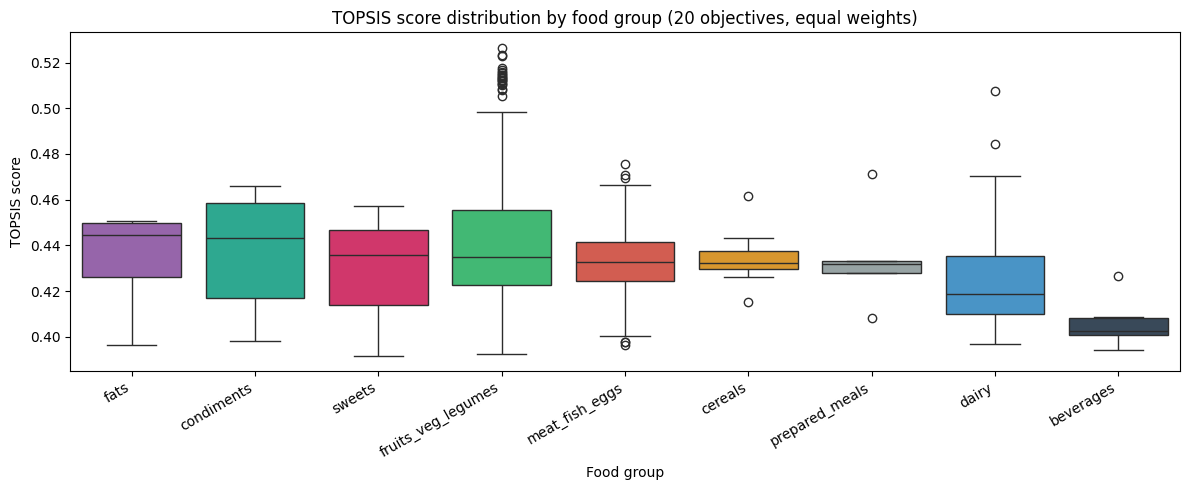

In [26]:
fig, ax = plt.subplots(figsize=(12, 5))
group_order = df_valid.groupby("group_en")["topsis_score"].median().sort_values(ascending=False).index
sns.boxplot(
    data=df_valid[df_valid["group_en"].isin(group_order)],
    x="group_en", y="topsis_score", order=group_order,
    palette={g: PALETTE.get(g, PALETTE["default"]) for g in group_order}, ax=ax,
)
ax.set_xlabel("Food group")
ax.set_ylabel("TOPSIS score")
ax.set_title("TOPSIS score distribution by food group (20 objectives, equal weights)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Sensitivity Analysis

In [27]:
SCENARIOS = {
    "Balanced":        {"weights": None,                                       "label": "Equal weight on all 20 objectives"},
    "Eco-conscious":   {"weights": {"co2_per_1000kcal": 4.0},                  "label": "4× CO2 penalty"},
    "Budget":          {"weights": {"price_per_1000kcal": 4.0},                "label": "4× price penalty"},
    "Nutrition-first": {"weights": {c: 3.0 for c in MAXIMIZE_COLS},            "label": "3× weight on all beneficial nutrients"},
}

scenario_rankings = {}
for name, cfg in SCENARIOS.items():
    s = topsis(df_valid, MINIMIZE_COLS, MAXIMIZE_COLS, cfg["weights"])
    tmp = df_valid.copy()
    tmp["topsis_score"] = s
    top10_names = tmp.nlargest(10, "topsis_score")["description"].tolist()
    scenario_rankings[name] = top10_names
    print(f"\n{name} ({cfg['label']}) — Top 10:")
    for i, food in enumerate(top10_names, 1):
        print(f"  {i:2d}. {food}")


Balanced (Equal weight on all 20 objectives) — Top 10:
   1. Spinach, mature
   2. Kale, raw
   3. Spinach, baby
   4. Beans, Dry, Flor de Mayo (0% moisture)
   5. Beans, Dry, Medium Red (0% moisture)
   6. Beans, Dry, Red (0% moisture)
   7. Beans, Dry, Light Red Kidney (0% moisture)
   8. Beans, Dry, Small White (0% moisture)
   9. Beans, Dry, Pinto (0% moisture)
  10. Beans, Dry, Great Northern (0% moisture)

Eco-conscious (4× CO2 penalty) — Top 10:
   1. Kale, raw
   2. Beans, Dry, Medium Red (0% moisture)
   3. Beans, Dry, Flor de Mayo (0% moisture)
   4. Beans, Dry, Red (0% moisture)
   5. Beans, Dry, Small White (0% moisture)
   6. Beans, Dry, Light Red Kidney (0% moisture)
   7. Beans, Dry, Pinto (0% moisture)
   8. Beans, Dry, Great Northern (0% moisture)
   9. Beans, Dry, Navy (0% moisture)
  10. Beans, Dry, Tan (0% moisture)

Budget (4× price penalty) — Top 10:
   1. Spinach, mature
   2. Beans, Dry, Medium Red (0% moisture)
   3. Beans, Dry, Flor de Mayo (0% moisture)
   4

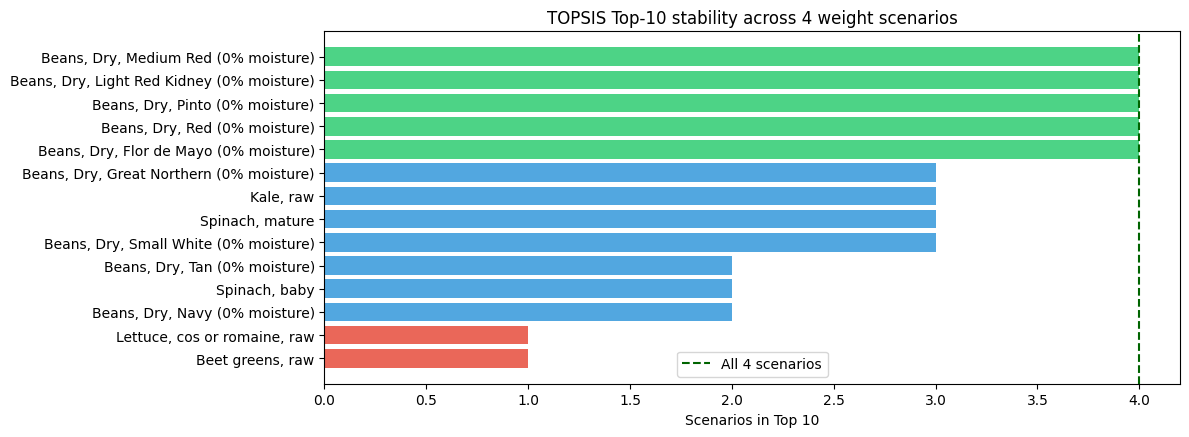


Robust in all 4 scenarios: 5
['Beans, Dry, Medium Red (0% moisture)', 'Beans, Dry, Light Red Kidney (0% moisture)', 'Beans, Dry, Pinto (0% moisture)', 'Beans, Dry, Red (0% moisture)', 'Beans, Dry, Flor de Mayo (0% moisture)']


In [28]:
all_top = set(f for v in scenario_rankings.values() for f in v)
stab = {f: sum(f in v for v in scenario_rankings.values()) for f in all_top}
stab_df = pd.Series(stab).sort_values(ascending=False).reset_index()
stab_df.columns = ["food", "n_scenarios"]

fig, ax = plt.subplots(figsize=(12, max(4, len(stab_df) * 0.32)))
bar_c = ["#2ecc71" if n == len(SCENARIOS) else "#3498db" if n >= 2 else "#e74c3c"
         for n in stab_df["n_scenarios"]]
ax.barh(stab_df["food"], stab_df["n_scenarios"], color=bar_c, alpha=0.85)
ax.axvline(len(SCENARIOS), ls="--", color="darkgreen", label=f"All {len(SCENARIOS)} scenarios")
ax.set_xlabel("Scenarios in Top 10")
ax.set_title(f"TOPSIS Top-10 stability across {len(SCENARIOS)} weight scenarios")
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()

robust = stab_df[stab_df["n_scenarios"] >= 4]
print(f"\nRobust in all {len(SCENARIOS)} scenarios: {len(robust)}")
print(robust["food"].tolist())

### What does "robust across all scenarios" mean in practice?

A food that appears in the top TOPSIS tier across all weighting scenarios is **value-judgment-independent**: it performs well whether you prioritize cost, environmental footprint, or specific micronutrients. This is a stronger claim than simply having the highest TOPSIS score under equal weights.

In practical dietary terms, robust foods are the safest recommendations — they remain near the top of the ranking even if the decision-maker's priorities shift significantly. Foods that appear only under one or two scenarios are conditionally optimal: excellent choices given a specific set of priorities, but potentially poor choices under different ones.

For diet formulation, robust foods are candidates for a "core" that stays fixed across dietary strategies, while scenario-specific foods can be swapped in or out depending on the user's actual goals.

## 5. Random Diet TOPSIS (Product-Based)

Generate **N_DIETS** (default 100k) random 2000-kcal diets, score each with TOPSIS, plot top-N_TOP_DIETS highlighted over a grey random sample.

In [29]:
np.random.seed(RANDOM_SEED)

df_prod = df_valid[df_valid["Energy [kcal]"] > 0].reset_index(drop=True)
print(f"Products for diet sampling: {len(df_prod)}")

prod_matrix = df_prod[ALL_OBJ_COLS].values.astype(float)
prod_desc   = df_prod["description"].values
n_foods = len(df_prod)

# Pre-allocate result arrays for speed
diet_obj   = np.zeros((N_DIETS, len(ALL_OBJ_COLS)), dtype=np.float32)
diet_sizes = np.zeros(N_DIETS, dtype=np.int8)
diet_prods = [None] * N_DIETS

for i in range(N_DIETS):
    n_items = 5 if np.random.rand() < 0.5 else 10
    scale   = (2000 / n_items) / 1000.0
    idxs    = np.random.choice(n_foods, n_items, replace=False)
    diet_obj[i]   = prod_matrix[idxs].sum(axis=0) * scale
    diet_sizes[i] = n_items
    diet_prods[i] = "; ".join(prod_desc[idxs])

diets_df = pd.DataFrame(diet_obj, columns=ALL_OBJ_COLS)
diets_df["n_items"]  = diet_sizes
diets_df["products"] = diet_prods
print(f"Generated {len(diets_df):,} diets")
print(f"  5-product: {(diets_df['n_items']==5).sum():,}  |  10-product: {(diets_df['n_items']==10).sum():,}")

Products for diet sampling: 357
Generated 1,000,000 diets
  5-product: 499,977  |  10-product: 500,023


In [30]:
print("Computing TOPSIS scores for all diets...")
diets_df["topsis_score"] = topsis(diets_df, MINIMIZE_COLS, MAXIMIZE_COLS)
top_diets = diets_df.nlargest(N_TOP_DIETS, "topsis_score")
print(f"TOPSIS score range: [{diets_df['topsis_score'].min():.4f}, {diets_df['topsis_score'].max():.4f}]")
print(f"Top-{N_TOP_DIETS} threshold: {top_diets['topsis_score'].min():.4f}")

Computing TOPSIS scores for all diets...
TOPSIS score range: [0.3556, 0.5596]
Top-50 threshold: 0.5389


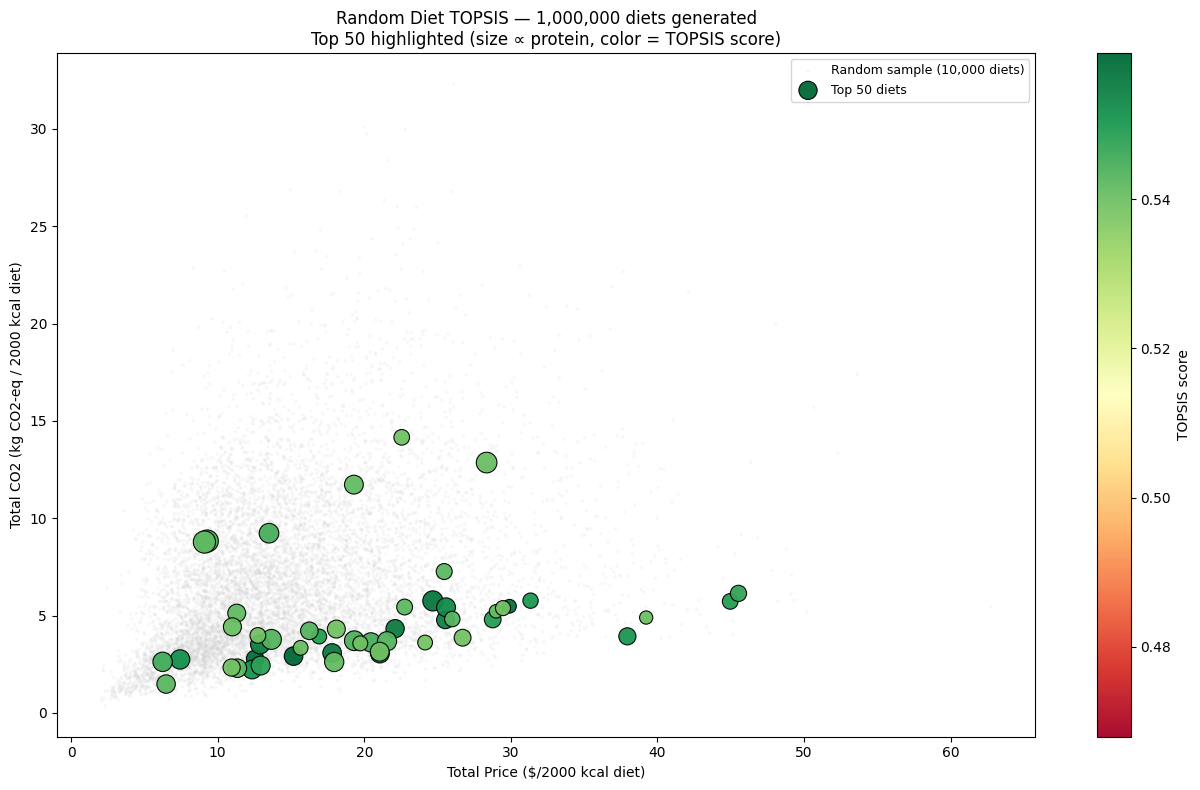

In [31]:
# Random grey sample from non-top diets
non_top = diets_df[~diets_df.index.isin(top_diets.index)]
grey_sample = non_top.sample(min(N_GREY_SAMPLE, len(non_top)), random_state=RANDOM_SEED)

fig, ax = plt.subplots(figsize=(13, 8))
ax.scatter(
    grey_sample["price_per_1000kcal"], grey_sample["co2_per_1000kcal"],
    c="#cccccc", alpha=0.15, s=6, edgecolors="none", label=f"Random sample ({N_GREY_SAMPLE:,} diets)",
)

sc = ax.scatter(
    top_diets["price_per_1000kcal"], top_diets["co2_per_1000kcal"],
    c=top_diets["topsis_score"], cmap="RdYlGn",
    s=top_diets["Protein_per_1000kcal"] * 0.5 + 30,
    edgecolors="black", linewidths=0.8, zorder=3, alpha=0.95,
    vmin=diets_df["topsis_score"].quantile(0.95),
    vmax=diets_df["topsis_score"].max(),
    label=f"Top {N_TOP_DIETS} diets",
)
plt.colorbar(sc, ax=ax, label="TOPSIS score")

ax.set_xlabel("Total Price ($/2000 kcal diet)")
ax.set_ylabel("Total CO2 (kg CO2-eq / 2000 kcal diet)")
ax.set_title(
    f"Random Diet TOPSIS — {N_DIETS:,} diets generated\n"
    f"Top {N_TOP_DIETS} highlighted (size ∝ protein, color = TOPSIS score)"
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [32]:
print(f"Top 10 diets by TOPSIS score (from {N_DIETS:,} sampled):")
for i, (_, row) in enumerate(top_diets.head(10).iterrows(), 1):
    print(f"\n#{i} ({int(row['n_items'])}-product diet, TOPSIS={row['topsis_score']:.4f})")
    print(f"  Price: ${row['price_per_1000kcal']:.2f}/2000kcal  "
          f"CO2: {row['co2_per_1000kcal']:.3f} kg  "
          f"Protein: {row['Protein_per_1000kcal']:.1f} g")
    for p in row["products"].split("; "):
        print(f"    - {p}")

Top 10 diets by TOPSIS score (from 1,000,000 sampled):

#1 (5-product diet, TOPSIS=0.5596)
  Price: $15.17/2000kcal  CO2: 2.915 kg  Protein: 297.4 g
    - Beans, Dry, Light Tan (0% moisture)
    - Beans, Dry, Pink (0% moisture)
    - Beans, Dry, Light Red Kidney (0% moisture)
    - Almond milk, unsweetened, plain, shelf stable
    - Peppers, bell, red, raw

#2 (5-product diet, TOPSIS=0.5580)
  Price: $12.55/2000kcal  CO2: 2.777 kg  Protein: 253.4 g
    - Soy milk, sweetened, plain, refrigerated
    - Kale, raw
    - Beans, Dry, Cranberry (0% moisture)
    - Beans, Dry, Light Red Kidney (0% moisture)
    - Peppers, bell, red, raw

#3 (5-product diet, TOPSIS=0.5577)
  Price: $29.91/2000kcal  CO2: 5.477 kg  Protein: 135.3 g
    - Flour, coconut
    - Peppers, poblano, seeded, raw
    - Spinach, baby
    - Almond milk, unsweetened, plain, shelf stable
    - Spinach, mature

#4 (5-product diet, TOPSIS=0.5566)
  Price: $24.68/2000kcal  CO2: 5.752 kg  Protein: 359.4 g
    - Beans, Dry, Dark R

## 6. Group-Based Diet TOPSIS

**N_DIETS** diets: sample 10 food groups (with replacement), pick one product per group slot.  
10 products × 200 kcal = 2000 kcal total. Ranked by TOPSIS.

In [33]:
np.random.seed(RANDOM_SEED)

group_lookup = {}
for grp, grp_df in df_prod.groupby("group_en"):
    group_lookup[grp] = grp_df.index.tolist()

valid_groups = sorted(g for g, idxs in group_lookup.items() if len(idxs) >= 1)
print(f"Valid groups ({len(valid_groups)}): {valid_groups}")

SCALE_G = 200 / 1000.0  # 200 kcal per product

g_obj   = []
g_ugrp  = []
g_grps  = []
g_prods = []

attempts = 0
while len(g_obj) < N_DIETS and attempts < N_DIETS * 3:
    attempts += 1
    sel = np.random.choice(valid_groups, 10, replace=True).tolist()
    chosen, used, ok = [], set(), True
    for grp in sel:
        candidates = [i for i in group_lookup[grp] if i not in used]
        if not candidates:
            ok = False; break
        picked = np.random.choice(candidates)
        chosen.append(picked)
        used.add(picked)
    if not ok:
        continue
    g_obj.append(prod_matrix[chosen].sum(axis=0) * SCALE_G)
    g_ugrp.append(len(set(sel)))
    g_grps.append("; ".join(sel))
    g_prods.append("; ".join(prod_desc[chosen]))

gdiets_df = pd.DataFrame(np.array(g_obj, dtype=np.float32), columns=ALL_OBJ_COLS)
gdiets_df["n_unique_groups"] = g_ugrp
gdiets_df["groups"]   = g_grps
gdiets_df["products"] = g_prods
print(f"Generated {len(gdiets_df):,} group-based diets ({attempts:,} attempts)")
print(f"Avg unique groups per diet: {gdiets_df['n_unique_groups'].mean():.1f}")

Valid groups (9): ['beverages', 'cereals', 'condiments', 'dairy', 'fats', 'fruits_veg_legumes', 'meat_fish_eggs', 'prepared_meals', 'sweets']
Generated 1,000,000 group-based diets (1,019,282 attempts)
Avg unique groups per diet: 6.2


Computing TOPSIS scores for group-based diets...


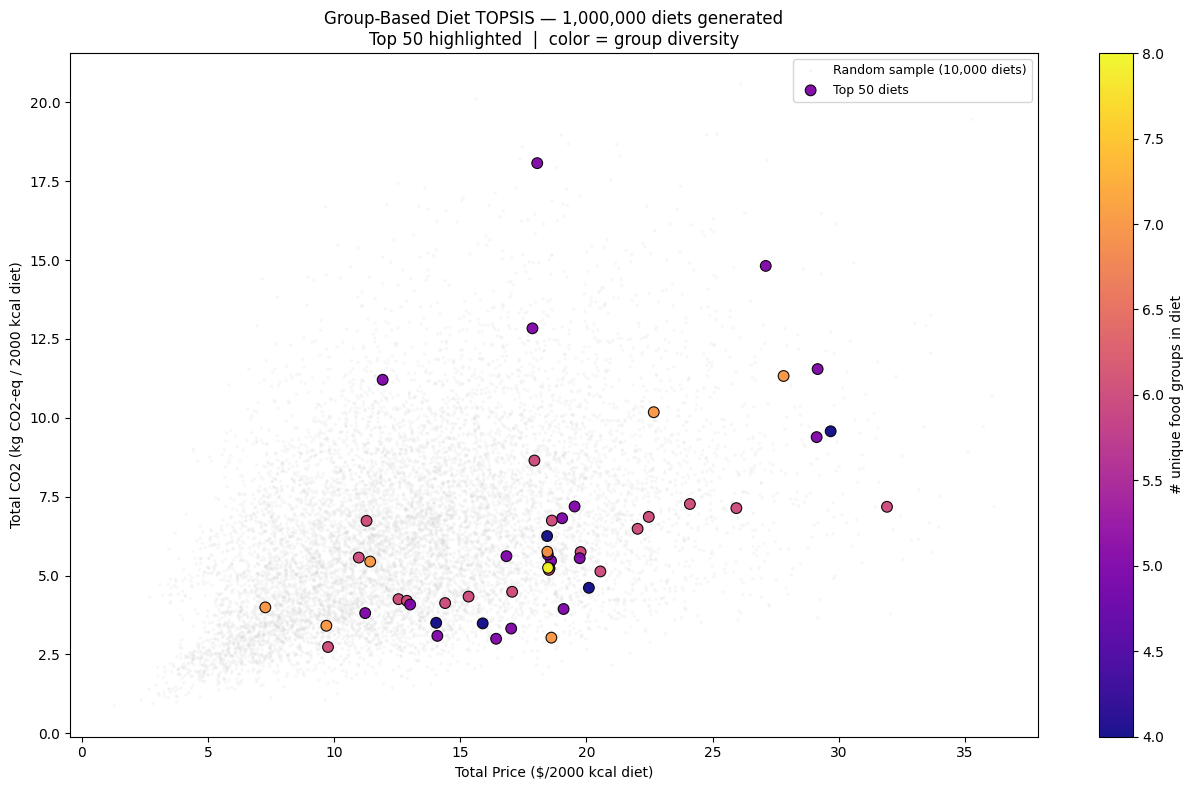

In [34]:
print("Computing TOPSIS scores for group-based diets...")
gdiets_df["topsis_score"] = topsis(gdiets_df, MINIMIZE_COLS, MAXIMIZE_COLS)
top_gdiets = gdiets_df.nlargest(N_TOP_DIETS, "topsis_score")

non_top_g = gdiets_df[~gdiets_df.index.isin(top_gdiets.index)]
grey_g    = non_top_g.sample(min(N_GREY_SAMPLE, len(non_top_g)), random_state=RANDOM_SEED)

fig, ax = plt.subplots(figsize=(13, 8))
ax.scatter(
    grey_g["price_per_1000kcal"], grey_g["co2_per_1000kcal"],
    c="#cccccc", alpha=0.15, s=6, edgecolors="none", label=f"Random sample ({N_GREY_SAMPLE:,} diets)",
)
sc = ax.scatter(
    top_gdiets["price_per_1000kcal"], top_gdiets["co2_per_1000kcal"],
    c=top_gdiets["n_unique_groups"], cmap="plasma",
    s=60, edgecolors="black", linewidths=0.8, zorder=3, alpha=0.95,
    label=f"Top {N_TOP_DIETS} diets",
)
plt.colorbar(sc, ax=ax, label="# unique food groups in diet")
ax.set_xlabel("Total Price ($/2000 kcal diet)")
ax.set_ylabel("Total CO2 (kg CO2-eq / 2000 kcal diet)")
ax.set_title(
    f"Group-Based Diet TOPSIS — {len(gdiets_df):,} diets generated\n"
    f"Top {N_TOP_DIETS} highlighted  |  color = group diversity"
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [35]:
print(f"Top 10 group-based diets by TOPSIS (from {len(gdiets_df):,} sampled):")
for i, (_, row) in enumerate(top_gdiets.head(10).iterrows(), 1):
    print(f"\n#{i} ({int(row['n_unique_groups'])} unique groups, TOPSIS={row['topsis_score']:.4f})")
    print(f"  Price: ${row['price_per_1000kcal']:.2f}/2000kcal  "
          f"CO2: {row['co2_per_1000kcal']:.3f} kg  "
          f"Protein: {row['Protein_per_1000kcal']:.1f} g")
    print(f"  Groups: {row['groups']}")
    for p in row["products"].split("; "):
        print(f"    - {p}")

Top 10 group-based diets by TOPSIS (from 1,000,000 sampled):

#1 (5 unique groups, TOPSIS=0.5783)
  Price: $27.10/2000kcal  CO2: 14.815 kg  Protein: 201.8 g
  Groups: prepared_meals; fruits_veg_legumes; fruits_veg_legumes; prepared_meals; condiments; condiments; fruits_veg_legumes; dairy; meat_fish_eggs; condiments
    - Crustaceans, crab, blue swimming, lump, pasteurized, refrigerated
    - Spinach, baby
    - Kale, raw
    - Sauce, pasta, spaghetti/marinara, ready-to-serve
    - Hummus, commercial
    - Mushroom, crimini
    - Beans, Dry, Pink (0% moisture)
    - Milk, nonfat, fluid, with added vitamin A and vitamin D (fat free or skim)
    - Arugula, baby, raw
    - Garlic, raw

#2 (6 unique groups, TOPSIS=0.5767)
  Price: $19.77/2000kcal  CO2: 5.745 kg  Protein: 169.7 g
  Groups: dairy; dairy; fruits_veg_legumes; fats; dairy; meat_fish_eggs; prepared_meals; cereals; fruits_veg_legumes; dairy
    - Cheese, cottage, lowfat, 2% milkfat
    - Almond milk, unsweetened, plain, shelf stab

## 7. Save

In [36]:
# Individual food ranking
save_food = ["description", "group_en", "topsis_score"] + ALL_OBJ_COLS
df_valid.sort_values("topsis_score", ascending=False)[save_food].to_csv(
    "foundation_topsis_ranking.csv", index=False
)
print("Saved: foundation_topsis_ranking.csv", df_valid.shape)

# Top diet results
shared = ["price_per_1000kcal", "co2_per_1000kcal", "Protein_per_1000kcal",
          "Fiber_total_dietary_per_1000kcal", "topsis_score", "products"]

out_prod = top_diets.copy(); out_prod["diet_type"] = "product_random"
out_grp  = top_gdiets.copy(); out_grp["diet_type"] = "group_based"

pd.concat([
    out_prod[["diet_type"] + shared + ["n_items"]],
    out_grp[["diet_type"] + shared + ["n_unique_groups", "groups"]],
], ignore_index=True).to_csv("foundation_topsis_diets.csv", index=False)
print("Saved: foundation_topsis_diets.csv")

Saved: foundation_topsis_ranking.csv (357, 57)
Saved: foundation_topsis_diets.csv
